In [28]:
# Cell 1 — Load both CSVs and tag them
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# --- EDIT THESE TWO PATHS ---
CSV1_PATH = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v1/identification/geogaze_model_predictions_identification_cornetIDEN_01_29_26_SAMESHAPE_abovechance.csv"
CSV2_PATH = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/v1/individuation/geogaze_model_predictions_individuation_cornetIDIV_01_29_26_SAMESHAPE_abovechance.csv"

# Optional: labels that will show up in the legend
LABEL1 = "identification"
LABEL2 = "individuation"

df1 = pd.read_csv(CSV1_PATH).copy()
df2 = pd.read_csv(CSV2_PATH).copy()

df1["dataset"] = LABEL1
df2["dataset"] = LABEL2

df_long = pd.concat([df1, df2], ignore_index=True)

print("Combined rows:", len(df_long))
print("Datasets:", df_long["dataset"].value_counts().to_dict())
print("Conditions:", df_long["condition"].value_counts().to_dict())
print("Unique models:", df_long["model"].nunique())
print(df_long.head())



Combined rows: 78
Datasets: {'individuation': 48, 'identification': 30}
Conditions: {'spatial': 26, 'featural': 26, 'train': 13, 'conflict': 13}
Unique models: 13
                    model condition         test_image                target  \
0  cornetIDEN_maskL_bc_gc     train  test_bc_gc_LR.png  test_left_c_mask.png   
1  cornetIDEN_maskL_bc_gc   spatial  test_bc_bc_LR.png  test_left_c_mask.png   
2  cornetIDEN_maskL_bc_gc   spatial  test_gc_gc_LR.png  test_left_c_mask.png   
3  cornetIDEN_maskL_bc_gc  featural  test_bc_gc_UD.png    test_up_c_mask.png   
4  cornetIDEN_maskL_bc_gc  featural  test_gc_bc_UD.png  test_down_c_mask.png   

              distractor              prediction  choice  acc_continuous  \
0  test_right_c_mask.png  test_bc_gc_LR_mask.png     NaN        0.556575   
1  test_right_c_mask.png  test_bc_bc_LR_mask.png     NaN        0.370140   
2  test_right_c_mask.png  test_gc_gc_LR_mask.png     NaN        0.500000   
3   test_down_c_mask.png  test_bc_gc_UD_mask.png    

In [29]:
# Cell 2 — Filter conditions + compute per-model means (per dataset)
conds = ["train", "spatial", "featural", "conflict"]

# Keep only desired conditions
df_filt = df_long.query("condition in @conds").copy()

# Mean acc per (dataset, model, condition)
per_model = (
    df_filt
    .groupby(["dataset", "model", "condition"], as_index=False)["acc_continuous"]
    .mean()
    .rename(columns={"acc_continuous": "acc"})
)

# Convert proportion (0–1) to percent (0–100)
per_model["acc"] = per_model["acc"] * 100

print(per_model.head())


          dataset                   model condition        acc
0  identification  cornetIDEN_maskL_bc_gc  conflict  95.588235
1  identification  cornetIDEN_maskL_bc_gc  featural  74.080553
2  identification  cornetIDEN_maskL_bc_gc   spatial  43.506998
3  identification  cornetIDEN_maskL_bc_gc     train  55.657492
4  identification  cornetIDEN_maskR_bc_gc  conflict   0.000000


/tmp/ipykernel_628065/1264266231.py:20: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


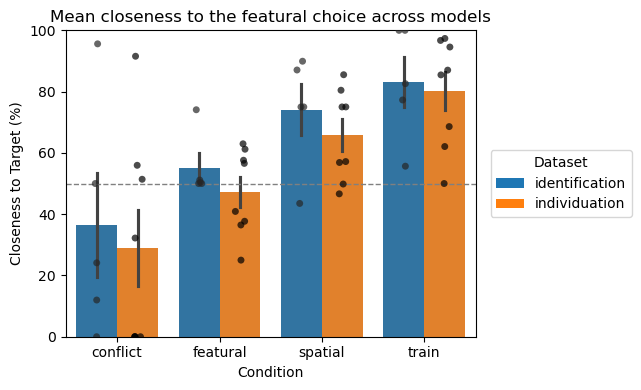

In [30]:
# Cell 3 — Plot: two bars per condition (one per CSV) + dots for each model
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

plt.figure(figsize=(8, 4))

# --- Bars (NO legend; we'll add our own) ---
ax = sns.barplot(
    data=per_model,
    x="condition",
    y="acc",
    hue="dataset",
    errorbar="se",
    dodge=True,
    legend=False
)

# --- Dots (NO legend; same hue, still dodge/jitter) ---
sns.stripplot(
    data=per_model,
    x="condition",
    y="acc",
    hue="dataset",
    dodge=True,
    jitter=True,
    alpha=0.7,
    color="black",
    legend=False,
    ax=ax
)

# --- Build a manual legend that matches the bar colors ---
datasets = list(per_model["dataset"].dropna().unique())
palette = sns.color_palette(n_colors=len(datasets))

handles = [Patch(facecolor=palette[i], edgecolor="none", label=datasets[i])
           for i in range(len(datasets))]

ax.legend(
    handles=handles,
    title="Dataset",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),  # outside to the right
    frameon=True
)

# --- Labels / cosmetics ---
ax.set_title("Mean closeness to the featural choice across models")
ax.set_xlabel("Condition")
ax.set_ylabel("Closeness to Target (%)")

ax.set_ylim(0, 100)
ax.axhline(y=50, linestyle="--", linewidth=1, color="gray")

# --- Make room on the right for the outside legend ---
plt.tight_layout(rect=[0, 0, 0.82, 1])

# --- Save (bbox_inches helps ensure the outside legend isn't cropped) ---
plt.savefig("iden_idiv_acc__SAMESHAPE_abovechance.png", dpi=300, bbox_inches="tight")
plt.show()
